In [1]:
!pip install opencv-python
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.neural_network import MLPClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import Perceptron


plt.savefig( "", format="eps", dpi=600, bbox_inches="tight" )

In [2]:
csv_path = "english.csv"
df = pd.read_csv(csv_path)


images = []
labels = []

for index, row in df.iterrows():
    img_path = row['image']   # Already includes Img/
    
    if not os.path.exists(img_path):
        print("File not found:", img_path)
        continue
        
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.resize(img, (28, 28))
        img = img.flatten() / 255.0
        images.append(img)
        labels.append(row['label'])

X = np.array(images)
y = np.array(labels)

print("Dataset Shape:", X.shape)

Dataset Shape: (3410, 2352)


In [3]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

num_classes = len(np.unique(y_encoded))

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [5]:
import numpy as np

def multiclass_perceptron_train(X, y, n_classes, lr=0.01, epochs=10, shuffle=True, seed=42):

    rng = np.random.default_rng(seed)
    n_samples, n_features = X.shape
    W = np.zeros((n_classes, n_features), dtype=np.float32)
    b = np.zeros(n_classes, dtype=np.float32)

    for ep in range(epochs):
        idx = np.arange(n_samples)
        if shuffle:
            rng.shuffle(idx)

        mistakes = 0
        for i in idx:
            scores = W @ X[i] + b
            y_hat = int(np.argmax(scores))
            y_true = int(y[i])

            if y_hat != y_true:
                mistakes += 1
                W[y_true] += lr * X[i]
                b[y_true] += lr
                W[y_hat]  -= lr * X[i]
                b[y_hat]  -= lr

        # optional: print progress
        print(f"Epoch {ep+1}/{epochs} | mistakes={mistakes}")

    return W, b

def multiclass_perceptron_predict(X, W, b):
    scores = X @ W.T + b
    return np.argmax(scores, axis=1)


In [6]:
def ovr_perceptron_train(X_train, y_train, lr=0.01, max_iter=1000, seed=42):
    base = Perceptron(eta0=lr, max_iter=max_iter, random_state=seed)
    model = OneVsRestClassifier(base)
    model.fit(X_train, y_train)
    return model

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def eval_and_save_cm(y_test, y_pred, name="model"):
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.savefig(f"{name}_confusion_matrix.eps", format="eps", dpi=600, bbox_inches="tight")
    plt.close()

    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


Epoch 1/10 | mistakes=2671
Epoch 2/10 | mistakes=2607
Epoch 3/10 | mistakes=2480
Epoch 4/10 | mistakes=2400
Epoch 5/10 | mistakes=2343
Epoch 6/10 | mistakes=2270
Epoch 7/10 | mistakes=2262
Epoch 8/10 | mistakes=2239
Epoch 9/10 | mistakes=2172
Epoch 10/10 | mistakes=2197

PLA_Regular_Multiclass
Accuracy: 0.13049853372434017
Precision: 0.1160783286539941
Recall: 0.13049853372434017
F1-score: 0.08262556684250409


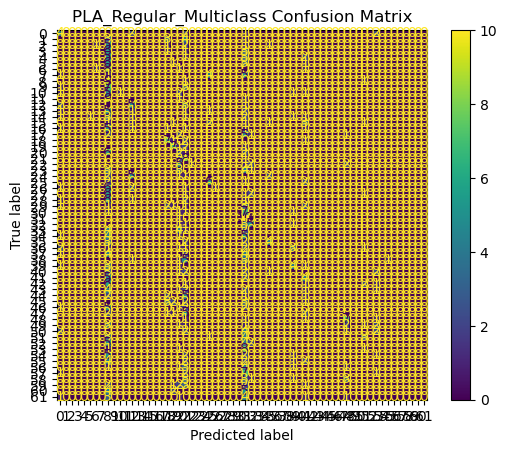


PLA_OneVsRest
Accuracy: 0.12023460410557185
Precision: 0.21436047469883324
Recall: 0.12023460410557185
F1-score: 0.08773768998068193


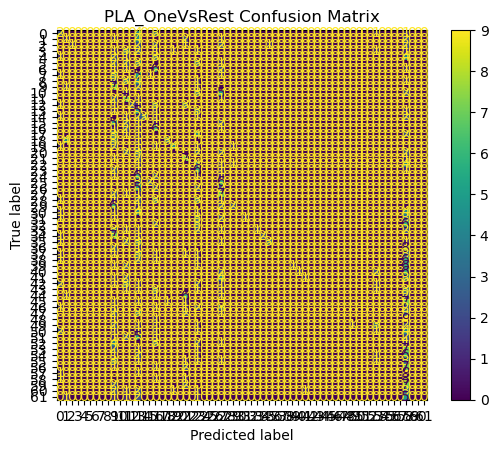

Average epochs: 15.193548387096774
Train Loss: 12.336079823065973


In [28]:
# n_classes = number of unique labels in y_train
n_classes = len(np.unique(y_train))

# Regular multiclass PLA (from scratch)
W, b = multiclass_perceptron_train(X_train, y_train, n_classes, lr=0.01, epochs=10)
y_pred_regular = multiclass_perceptron_predict(X_test, W, b)
metrics_regular = eval_and_save_cm(y_test, y_pred_regular, name="PLA_Regular_Multiclass")

# OvR PLA 
ovr_model = ovr_perceptron_train(X_train, y_train, lr=0.01, max_iter=1000)
y_pred_ovr = ovr_model.predict(X_test)
metrics_ovr = eval_and_save_cm(y_test, y_pred_ovr, name="PLA_OneVsRest")
avg_epochs = sum(est.n_iter_ for est in ovr_model.estimators_) / len(ovr_model.estimators_)
print("Average epochs:", avg_epochs)
def ovr_perceptron_loss(model, X, y):
    total_loss = 0
    
    for class_index, estimator in enumerate(model.estimators_):
        
        # Get weights
        w = estimator.coef_[0]
        b = estimator.intercept_[0]
        
        # Convert labels to +1/-1
        y_binary = np.where(y == class_index, 1, -1)
        
        # Compute margins
        margins = y_binary * (X @ w + b)
        
        # Perceptron loss
        loss = np.maximum(0, -margins)
        
        total_loss += np.sum(loss)
    
    return total_loss / len(y)
print("Train Loss:", ovr_perceptron_loss(ovr_model,X_train,y_train))

Due To the innacuracy of the pla, The confusion matrix also is shown to be very innacurate. It actually shows the pla from scratch to have better accuracy, but both are still bad accuracy.

In [9]:
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier

def fast_mlp(
    X_train, y_train, X_test, y_test,
    name="model",
    hidden_layer_sizes=(256,128),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=128,
    max_iter=120,            # can be large, but early_stopping will stop earlier
    random_state=42
):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        learning_rate_init=learning_rate_init,
        batch_size=batch_size,
        max_iter=max_iter,
        # Other:
        shuffle=True,
        random_state=random_state,
        verbose=False
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    metrics = {
        "name": name,
        "accuracy": acc,
        "precision_weighted": prec,
        "recall_weighted": rec,
        "f1_weighted": f1,
        "params": {
            "hidden_layer_sizes": hidden_layer_sizes,
            "activation": activation,
            "solver": solver,
            "learning_rate_init": learning_rate_init,
            "batch_size": batch_size,
            "max_iter": max_iter,
            "random_state": random_state
        }
    }

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")

    
    eps_path = f"{name}_confusion_matrix.eps"
    plt.savefig(eps_path, format="eps", dpi=600, bbox_inches="tight")


    plt.show()

    plt.close()
    print("Metrics: ",metrics)
    print("n_iter_:", model.n_iter_)
    print("final loss:", model.loss_)
    print(f"\n{name} Results")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)

    return model, metrics, y_pred

Even with a max of 90 iterations, the model fails to converge and give proper accuracy.

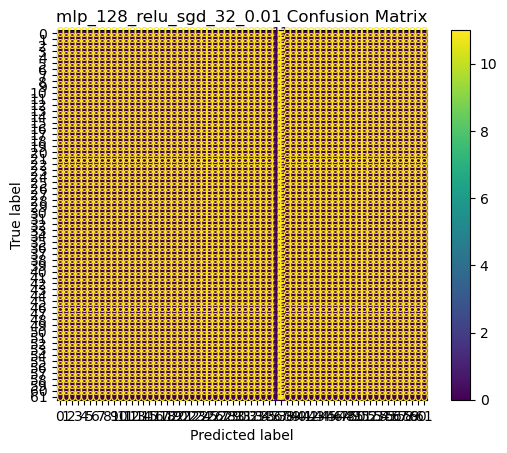

Metrics:  {'name': 'mlp_128_relu_sgd_32_0.01', 'accuracy': 0.016129032258064516, 'precision_weighted': 0.00026014568158168577, 'recall_weighted': 0.016129032258064516, 'f1_weighted': 0.0005120327700972862, 'params': {'hidden_layer_sizes': (128,), 'activation': 'relu', 'solver': 'sgd', 'learning_rate_init': 0.01, 'batch_size': 32, 'max_iter': 120, 'random_state': 42}}
n_iter_: 21
final loss: 4.1289170905058885

mlp_128_relu_sgd_32_0.01 Results
Accuracy: 0.016129032258064516
Precision: 0.00026014568158168577
Recall: 0.016129032258064516
F1-score: 0.0005120327700972862


In [10]:
mlp1, metrics1, y_pred_mlp1 = fast_mlp(
    X_train, y_train, X_test, y_test,
    name="mlp_128_relu_sgd_32_0.01",
    hidden_layer_sizes=(128,),
    activation="relu",
    solver="sgd",
    learning_rate_init=0.01,
    batch_size=32
)


SGD + Learning rate of 0.01 gives very poor accuracy in relu.

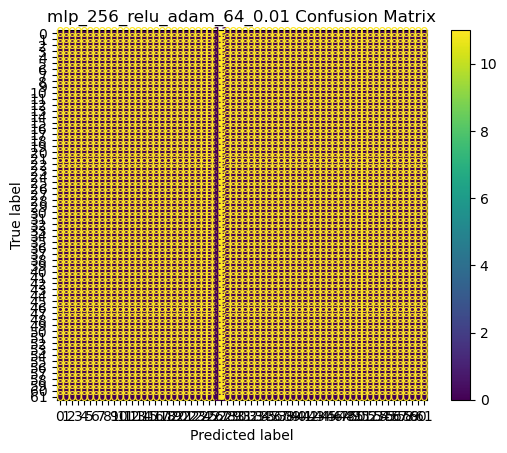

Metrics:  {'name': 'mlp_256_relu_adam_64_0.01', 'accuracy': 0.016129032258064516, 'precision_weighted': 0.00026014568158168577, 'recall_weighted': 0.016129032258064516, 'f1_weighted': 0.0005120327700972862, 'params': {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.01, 'batch_size': 64, 'max_iter': 120, 'random_state': 42}}
n_iter_: 22
final loss: 4.131160868399794

mlp_256_relu_adam_64_0.01 Results
Accuracy: 0.016129032258064516
Precision: 0.00026014568158168577
Recall: 0.016129032258064516
F1-score: 0.0005120327700972862


In [11]:
#Updating batch size = 64, lr = 0.01, solver = adam, activation = relu
mlp2, metrics2, y_pred_mlp2 = fast_mlp(
    X_train, y_train, X_test, y_test,
    name="mlp_256_relu_adam_64_0.01",
    hidden_layer_sizes=(256,128),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    batch_size=64
)

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (120) reached and the optimization hasn't converged yet.
  warnings.warn(


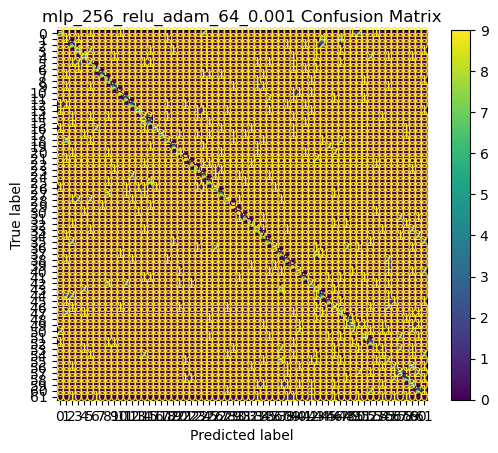

Metrics:  {'name': 'mlp_256_relu_adam_64_0.001', 'accuracy': 0.4090909090909091, 'precision_weighted': 0.44053881420742, 'recall_weighted': 0.4090909090909091, 'f1_weighted': 0.41049228456536563, 'params': {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.001, 'batch_size': 64, 'max_iter': 120, 'random_state': 42}}
n_iter_: 120
final loss: 0.9389333177333508

mlp_256_relu_adam_64_0.001 Results
Accuracy: 0.4090909090909091
Precision: 0.44053881420742
Recall: 0.4090909090909091
F1-score: 0.41049228456536563


In [12]:
#Updating batch size = 64, lr = 0.001, solver = adam, activation = relu
mlp3, metrics3, y_pred_mlp3 = fast_mlp(
    X_train, y_train, X_test, y_test,
    name="mlp_256_relu_adam_64_0.001",
    hidden_layer_sizes=(256,128),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=64
)

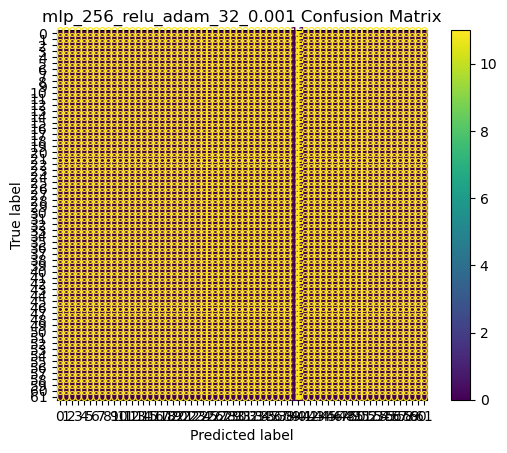

Metrics:  {'name': 'mlp_256_relu_adam_32_0.001', 'accuracy': 0.016129032258064516, 'precision_weighted': 0.00026014568158168577, 'recall_weighted': 0.016129032258064516, 'f1_weighted': 0.0005120327700972862, 'params': {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.001, 'batch_size': 32, 'max_iter': 120, 'random_state': 42}}
n_iter_: 13
final loss: 4.129427448158066

mlp_256_relu_adam_32_0.001 Results
Accuracy: 0.016129032258064516
Precision: 0.00026014568158168577
Recall: 0.016129032258064516
F1-score: 0.0005120327700972862


In [13]:
#Updating batch size = 32, lr = 0.001, solver = adam, activation = relu
mlp4, metrics4, y_pred_mlp4 = fast_mlp(
    X_train, y_train, X_test, y_test,
    name="mlp_256_relu_adam_32_0.001",
    hidden_layer_sizes=(256,128),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=32
)

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (120) reached and the optimization hasn't converged yet.
  warnings.warn(


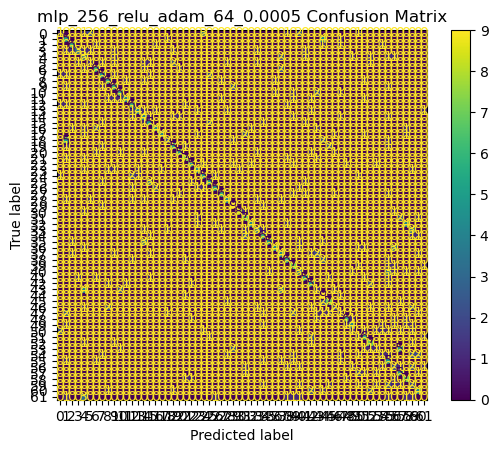

Metrics:  {'name': 'mlp_256_relu_adam_64_0.0005', 'accuracy': 0.40762463343108507, 'precision_weighted': 0.4290028201065863, 'recall_weighted': 0.40762463343108507, 'f1_weighted': 0.402879053715488, 'params': {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.0005, 'batch_size': 64, 'max_iter': 120, 'random_state': 42}}
n_iter_: 120
final loss: 1.140721558402153

mlp_256_relu_adam_64_0.0005 Results
Accuracy: 0.40762463343108507
Precision: 0.4290028201065863
Recall: 0.40762463343108507
F1-score: 0.402879053715488


In [16]:
mlp5, metrics5, y_pred_mlp5 = fast_mlp(
    X_train, y_train, X_test, y_test,
    name="mlp_256_relu_adam_64_0.0005",
    hidden_layer_sizes=(256,128),
    activation="relu",
    solver="adam",
    learning_rate_init=0.0005,
    batch_size=64
)

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (120) reached and the optimization hasn't converged yet.
  warnings.warn(


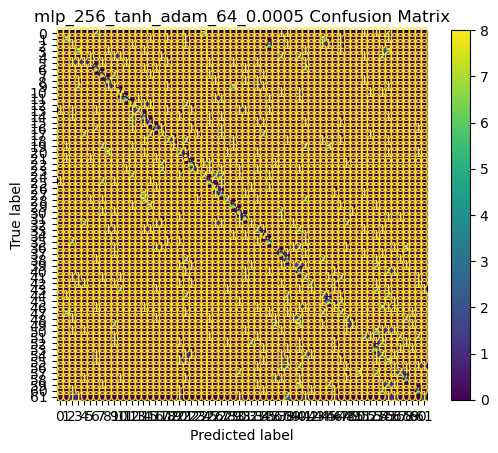

Metrics:  {'name': 'mlp_256_tanh_adam_64_0.0005', 'accuracy': 0.27712609970674484, 'precision_weighted': 0.2756806213943186, 'recall_weighted': 0.27712609970674484, 'f1_weighted': 0.25655597098590666, 'params': {'hidden_layer_sizes': (256, 128), 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.0005, 'batch_size': 64, 'max_iter': 120, 'random_state': 42}}
n_iter_: 120
final loss: 2.2493976740222728

mlp_256_tanh_adam_64_0.0005 Results
Accuracy: 0.27712609970674484
Precision: 0.2756806213943186
Recall: 0.27712609970674484
F1-score: 0.25655597098590666


In [17]:
mlp6, metrics6, y_pred_mlp6 = fast_mlp(
    X_train, y_train, X_test, y_test,
    name="mlp_256_tanh_adam_64_0.0005",
    hidden_layer_sizes=(256,128),
    activation="tanh",
    solver="adam",
    learning_rate_init=0.0005,
    batch_size=64
)

C:\Users\kisho\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (120) reached and the optimization hasn't converged yet.
  warnings.warn(


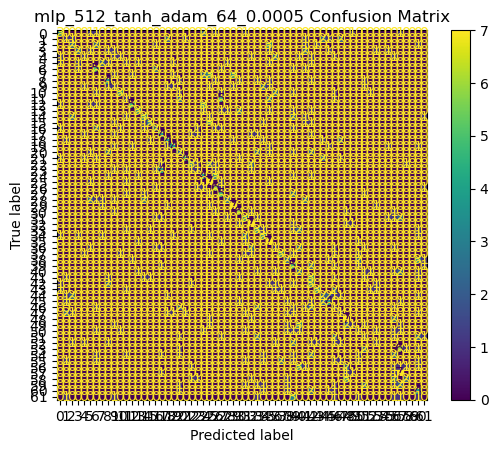

Metrics:  {'name': 'mlp_512_tanh_adam_64_0.0005', 'accuracy': 0.25219941348973607, 'precision_weighted': 0.24819366773473925, 'recall_weighted': 0.25219941348973607, 'f1_weighted': 0.23615431886195914, 'params': {'hidden_layer_sizes': (512, 256, 128), 'activation': 'tanh', 'solver': 'adam', 'learning_rate_init': 0.0005, 'batch_size': 64, 'max_iter': 120, 'random_state': 42}}
n_iter_: 120
final loss: 2.1579694775787575

mlp_512_tanh_adam_64_0.0005 Results
Accuracy: 0.25219941348973607
Precision: 0.24819366773473925
Recall: 0.25219941348973607
F1-score: 0.23615431886195914


In [18]:
mlp7, metrics7, y_pred_mlp7 = fast_mlp(
    X_train, y_train, X_test, y_test,
    name="mlp_512_tanh_adam_64_0.0005",
    hidden_layer_sizes=(512,256,128),
    activation="tanh",
    solver="adam",
    learning_rate_init=0.0005,
    batch_size=64
)

In [19]:
print(X_train.min(), X_train.max(), X_train.mean())

0.0 1.0 0.9416737497785037


In [20]:
print(y_train[:10])
print(type(y_train[0]))
print("num classes:", len(np.unique(y_train)))

[60 46 53 29  3 30 19 40  1 14]
<class 'numpy.int64'>
num classes: 62


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_multiple_mlp_roc(models_dict, X_test, y_test, filename="mlp_roc_comparison.eps"):

    from sklearn.preprocessing import label_binarize
    import numpy as np

    n_classes = len(np.unique(y_test))
    y_test_bin = label_binarize(y_test, classes=range(n_classes))

    plt.figure(figsize=(8,6))

    for name, model in models_dict.items():
        y_score = model.predict_proba(X_test)

        fpr, tpr, _ = roc_curve(
            y_test_bin.ravel(),
            y_score.ravel()
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("MLP ROC Curve Comparison (Micro-average)")
    plt.legend()

    plt.savefig(filename, format="eps", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


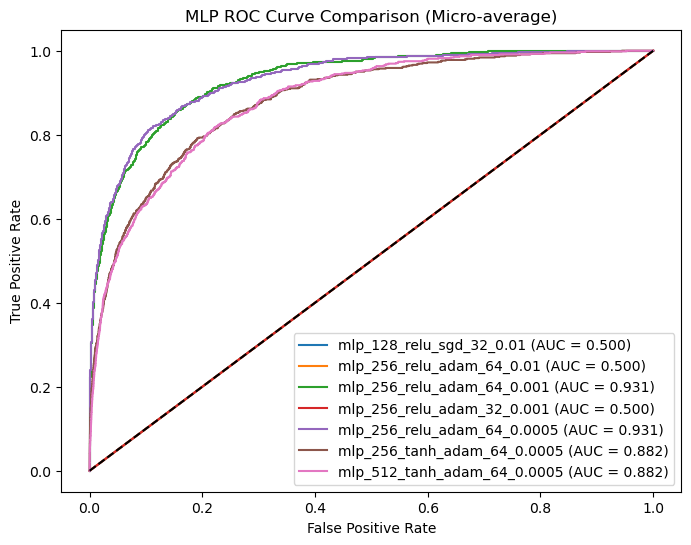

In [22]:
models = {
    "mlp_128_relu_sgd_32_0.01": mlp1,
    "mlp_256_relu_adam_64_0.01": mlp2,
    "mlp_256_relu_adam_64_0.001":mlp3,
    "mlp_256_relu_adam_32_0.001": mlp4,
    "mlp_256_relu_adam_64_0.0005":mlp5,
    "mlp_256_tanh_adam_64_0.0005":mlp6,
    "mlp_512_tanh_adam_64_0.0005":mlp7
}
plot_multiple_mlp_roc(models, X_test, y_test)

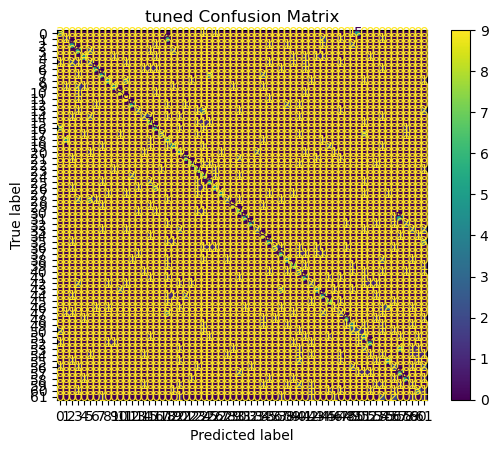

Metrics:  {'name': 'tuned', 'accuracy': 0.39296187683284456, 'precision_weighted': 0.4276555480927297, 'recall_weighted': 0.39296187683284456, 'f1_weighted': 0.39226256452999386, 'params': {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'solver': 'adam', 'learning_rate_init': 0.001, 'batch_size': 64, 'max_iter': 500, 'random_state': 42}}
n_iter_: 317
final loss: 0.1782432318026757

tuned Results
Accuracy: 0.39296187683284456
Precision: 0.4276555480927297
Recall: 0.39296187683284456
F1-score: 0.39226256452999386


In [29]:
mlptuned, metricstuned, y_pred_mlptuned = fast_mlp(
    X_train, y_train, X_test, y_test,
    name="tuned",
    hidden_layer_sizes=(256,128),
    activation="relu", 
    solver="adam",
    learning_rate_init=0.001,
    batch_size=64,
    max_iter=500
)

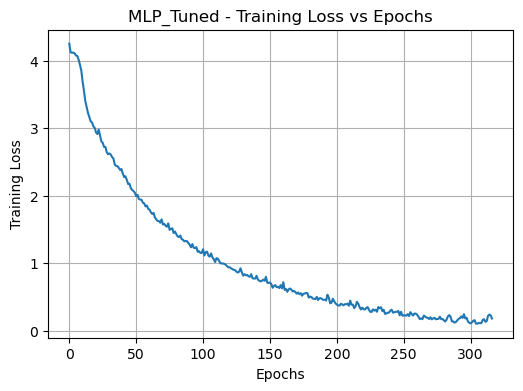

In [30]:
import matplotlib.pyplot as plt

def plot_training_loss(model, name="MLP", save=True):
    plt.figure(figsize=(6,4))
    plt.plot(model.loss_curve_)
    plt.xlabel("Epochs")
    plt.ylabel("Training Loss")
    plt.title(f"{name} - Training Loss vs Epochs")
    plt.grid(True)

    if save:
        plt.savefig(f"{name}_training_loss.eps",
                    format="eps",
                    dpi=600,
                    bbox_inches="tight")

    plt.show()
    plt.close()
plot_training_loss(mlptuned, name="MLP_Tuned")